In [1]:
# Install required libraries
# yfinance: to download stock data directly from Yahoo Finance
# No need to upload any dataset manually!
!pip install yfinance --quiet

In [2]:
# ─── Standard & Data Libraries ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ─── Scikit-learn for Preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ─── TensorFlow / Keras for Building the LSTM Model ──────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully ✅")

TensorFlow version: 2.20.0
All libraries loaded successfully ✅


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1: DATA PREPARATION
# We use Apple Inc. (AAPL) stock data from Jan 2019 to Jan 2024 (5 years)
# yfinance downloads this directly — no manual dataset needed!
# ─────────────────────────────────────────────────────────────────────────────

TICKER   = "AAPL"          # You can change this to any S&P 500 ticker
START    = "2019-01-01"
END      = "2024-01-01"

# Download historical OHLCV data from Yahoo Finance
df = yf.download(TICKER, start=START, end=END)

print(f"Downloaded {len(df)} trading days of {TICKER} data")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 trading days of AAPL data
Date range: 2019-01-02 → 2023-12-29

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800
2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


Shape of selected feature (Close price): (1258, 1)


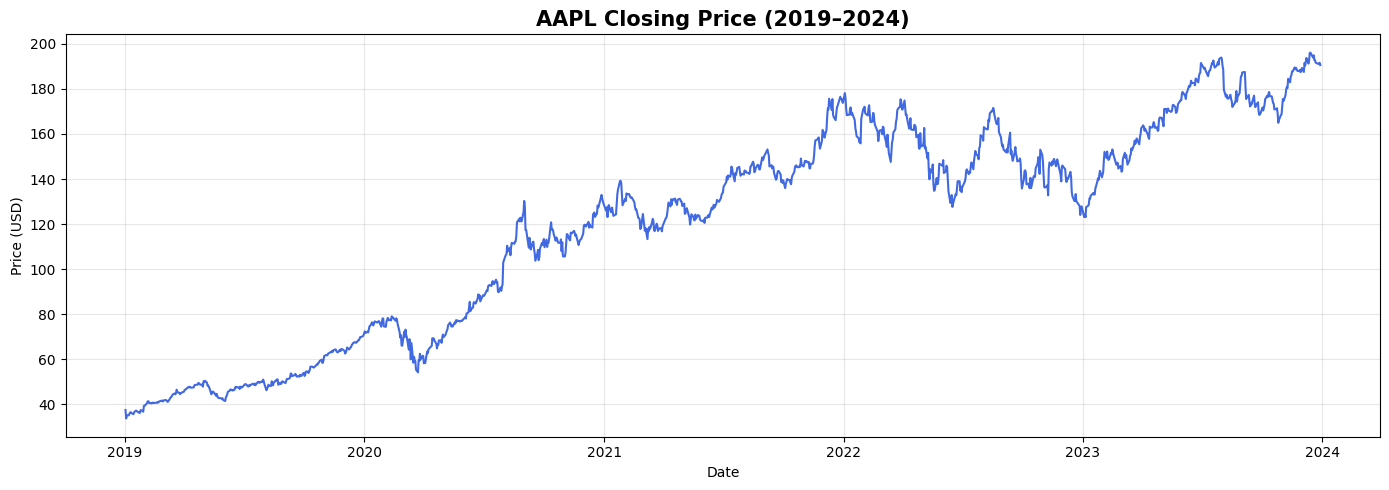

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE SELECTION + COLUMN FLATTENING
# yfinance newer versions return MultiIndex columns like ('Close', 'AAPL').
# We flatten them early so the rest of the notebook works cleanly.
# ─────────────────────────────────────────────────────────────────────────────

# Flatten MultiIndex columns
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

# Find and rename the Close column
close_col = [c for c in df.columns if 'Close' in c][0]
df = df.rename(columns={close_col: 'Close'})

# Select only the Close price column
close_prices = df[['Close']].copy()
print("Shape of selected feature (Close price):", close_prices.shape)

# ─── Visualise Raw Stock Prices ───────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(close_prices, color='royalblue', linewidth=1.5)
plt.title(f"{TICKER} Closing Price (2019–2024)", fontsize=15, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# NORMALIZATION / SCALING
# Fix: yfinance returns MultiIndex columns in newer versions, so we flatten them.
# ─────────────────────────────────────────────────────────────────────────────

# Flatten MultiIndex columns if present (e.g. ('Close', 'AAPL') → 'Close')
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

# Rename the close column to simply 'Close' for consistency
close_col = [c for c in df.columns if 'Close' in c][0]
df = df.rename(columns={close_col: 'Close'})

# Re-select close prices after fix
close_prices = df[['Close']].copy()

# Now scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("Original price range : {:.2f} → {:.2f}".format(
    float(close_prices['Close'].min()), float(close_prices['Close'].max())))
print("Scaled  value range  : {:.4f} → {:.4f}".format(
    float(scaled_data.min()), float(scaled_data.max())))

Original price range : 33.77 → 196.07
Scaled  value range  : 0.0000 → 1.0000


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SEQUENCE CREATION
# LSTMs learn from sequences. We use a sliding window of `look_back` days
# to predict the NEXT day's closing price.
#
# Example (look_back=60):
#   X[i] = prices on days [i, i+1, ..., i+59]   ← input sequence
#   y[i] = price on day   [i+60]                 ← target (what we predict)
# ─────────────────────────────────────────────────────────────────────────────

LOOK_BACK = 60   # Number of past days used to predict the next day

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back : i, 0])   # past 60 days
        y.append(data[i, 0])                    # next day price
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

# ─── Train / Test Split (80% train, 20% test) ─────────────────────────────────
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ─── Reshape for LSTM: (samples, time_steps, features) ────────────────────────
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")
print(f"Input shape (LSTM): {X_train.shape}  → (samples, timesteps, features)")

Training samples  : 958
Testing  samples  : 240
Input shape (LSTM): (958, 60, 1)  → (samples, timesteps, features)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2: MODEL DEVELOPMENT
# Architecture:
#   • LSTM Layer 1 (100 units, return_sequences=True) — extracts temporal patterns
#   • Dropout(0.2) — regularization to prevent overfitting
#   • LSTM Layer 2 (100 units) — deeper temporal learning
#   • Dropout(0.2)
#   • Dense(50) — intermediate fully-connected layer
#   • Dense(1)  — final output: predicted next-day closing price
#
# Why LSTM?
#   Standard RNNs suffer from the "vanishing gradient" problem — they forget
#   information from many steps back. LSTM cells have "gates" (input, forget,
#   output) that selectively remember or forget information, making them ideal
#   for long time-series like stock prices.
# ─────────────────────────────────────────────────────────────────────────────

tf.random.set_seed(42)

model = Sequential([
    # Layer 1: LSTM with 100 units — returns full sequence for next LSTM
    LSTM(units=100, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),   # Drop 20% of neurons randomly to reduce overfitting

    # Layer 2: LSTM with 100 units — processes the sequence further
    LSTM(units=100, return_sequences=False),
    Dropout(0.2),

    # Fully connected layers to map learned features → price
    Dense(units=50, activation='relu'),
    Dense(units=1)   # Single output: predicted closing price (scaled)
])

# ─── Compile: Adam optimizer + MSE loss ──────────────────────────────────────
# Adam adapts the learning rate automatically — great for noisy financial data
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3: TRAINING
# • Epochs: 25  — number of full passes over the training data
# • Batch size: 32 — samples per gradient update (smaller = noisier but often better)
# • Validation split: 10% of training data used to monitor overfitting
# ─────────────────────────────────────────────────────────────────────────────

history = model.fit(
    X_train, y_train,
    epochs          = 25,
    batch_size      = 32,
    validation_split= 0.10,
    verbose         = 1
)

print("\nTraining complete ✅")

Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step - loss: 0.0336 - val_loss: 0.0025
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 9/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 10/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 11/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 12/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/ste

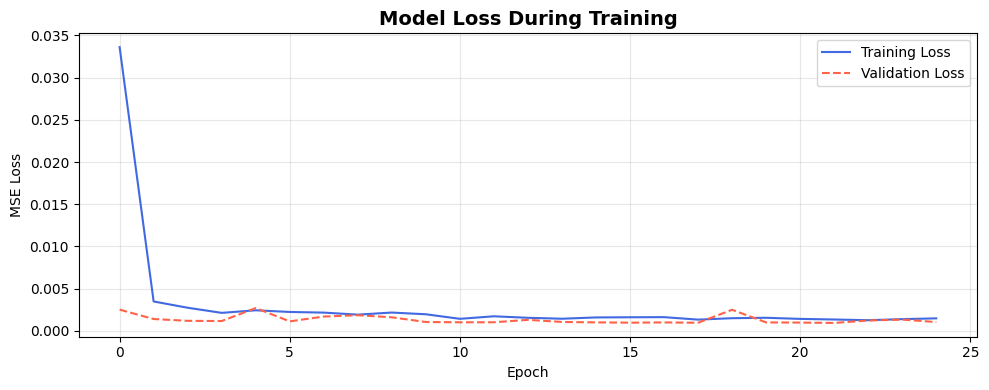

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE TRAINING vs VALIDATION LOSS
# If both curves decrease and stay close together → model is learning well.
# A large gap means overfitting (model memorised training data).
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
plt.title("Model Loss During Training", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4: PREDICTION
# We predict on the test set and then inverse-transform the scaled values
# back to actual USD prices for meaningful evaluation.
# ─────────────────────────────────────────────────────────────────────────────

# Generate predictions (scaled values)
predicted_scaled = model.predict(X_test)

# Inverse transform → back to real USD prices
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices    = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Sample predictions (USD): {predicted_prices[:5].flatten().round(2)}")
print(f"Sample actuals    (USD): {actual_prices[:5].flatten().round(2)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Sample predictions (USD): [130.92 131.93 132.79 133.71 134.84]
Sample actuals    (USD): [133.08 133.14 135.69 138.88 140.28]


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PERFORMANCE METRICS
#
#  MAE  (Mean Absolute Error)        — Average absolute dollar error
#  RMSE (Root Mean Squared Error)    — Penalises large errors more heavily
#  MAPE (Mean Absolute % Error)      — Error as a % of actual price (scale-free)
#
# Lower values = better model performance.
# ─────────────────────────────────────────────────────────────────────────────

mae  = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print("=" * 40)
print("        MODEL PERFORMANCE METRICS")
print("=" * 40)
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

        MODEL PERFORMANCE METRICS
  MAE  : $4.19
  RMSE : $4.93
  MAPE : 2.40%


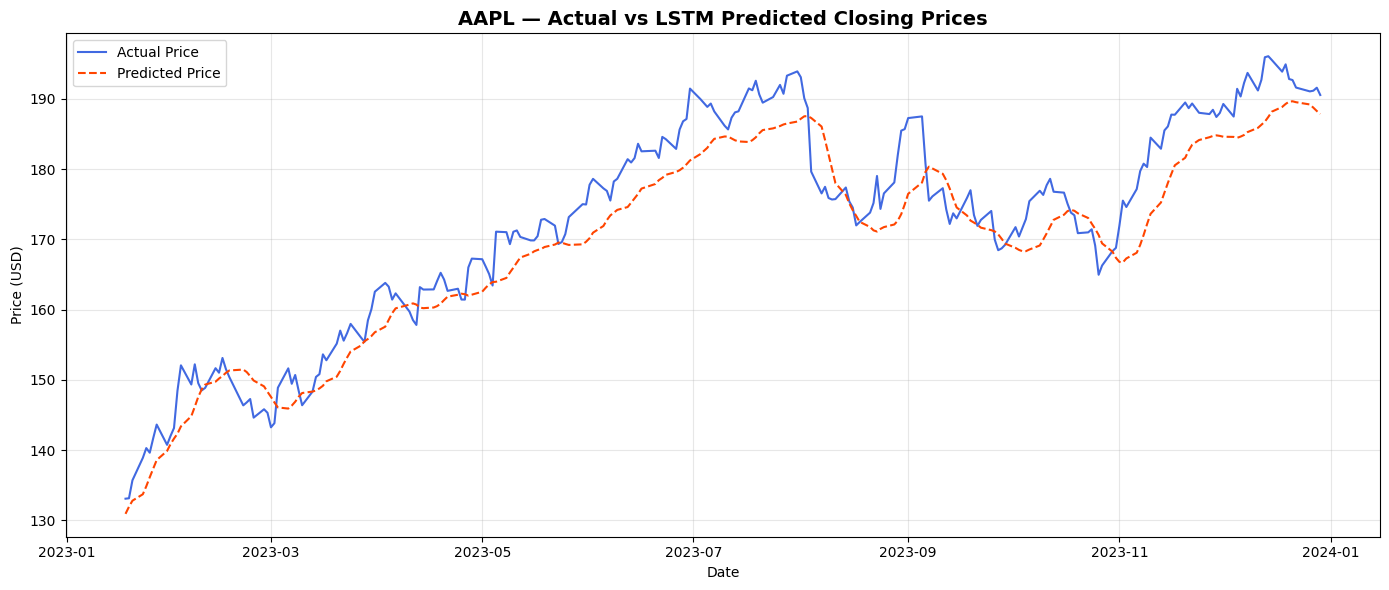

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION: Actual vs Predicted Stock Prices
# ─────────────────────────────────────────────────────────────────────────────

# Align dates with test set
test_dates = close_prices.index[split + LOOK_BACK:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actual_prices,    label='Actual Price',    color='royalblue',  linewidth=1.5)
plt.plot(test_dates, predicted_prices, label='Predicted Price', color='orangered',  linewidth=1.5, linestyle='--')
plt.title(f"{TICKER} — Actual vs LSTM Predicted Closing Prices", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

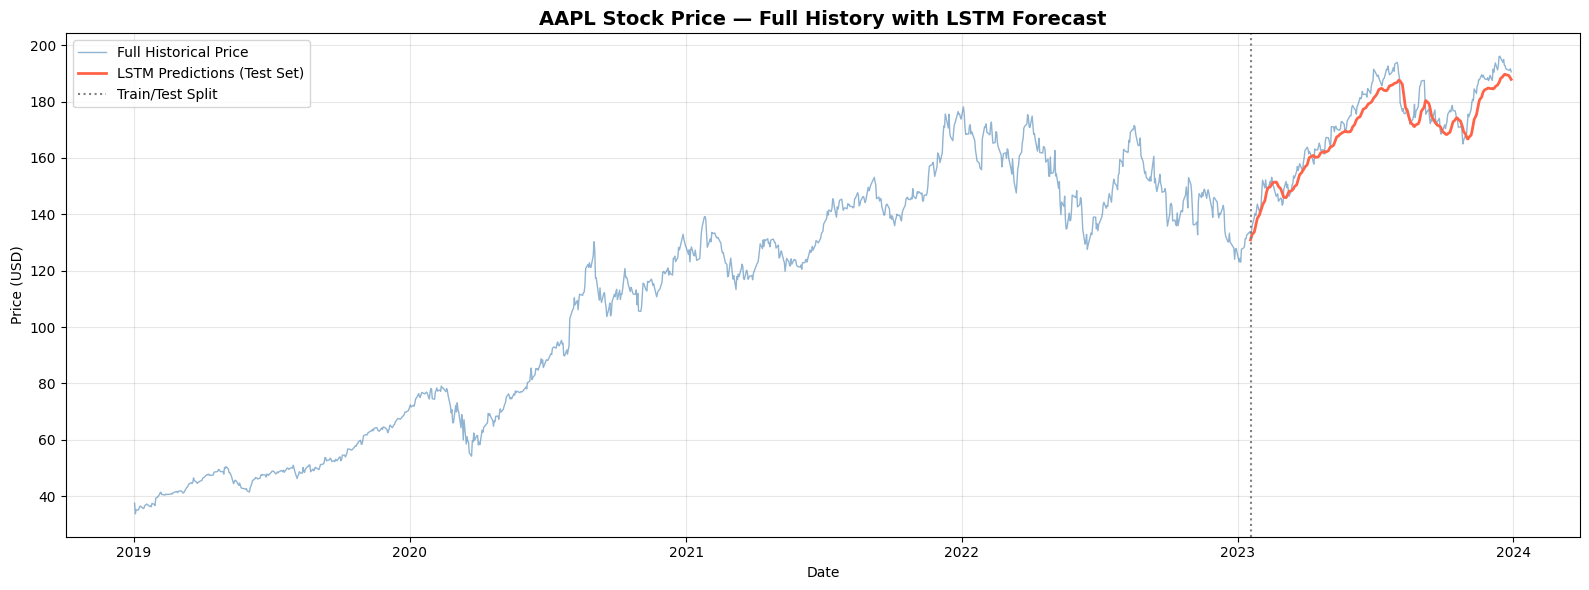

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# BONUS VISUALISATION: Full historical data with predictions overlaid on test window
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(16, 6))
plt.plot(close_prices.index, close_prices['Close'],
         label='Full Historical Price', color='steelblue', linewidth=1, alpha=0.6)
plt.plot(test_dates, predicted_prices,
         label='LSTM Predictions (Test Set)', color='tomato', linewidth=2)
plt.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')
plt.title(f"{TICKER} Stock Price — Full History with LSTM Forecast", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

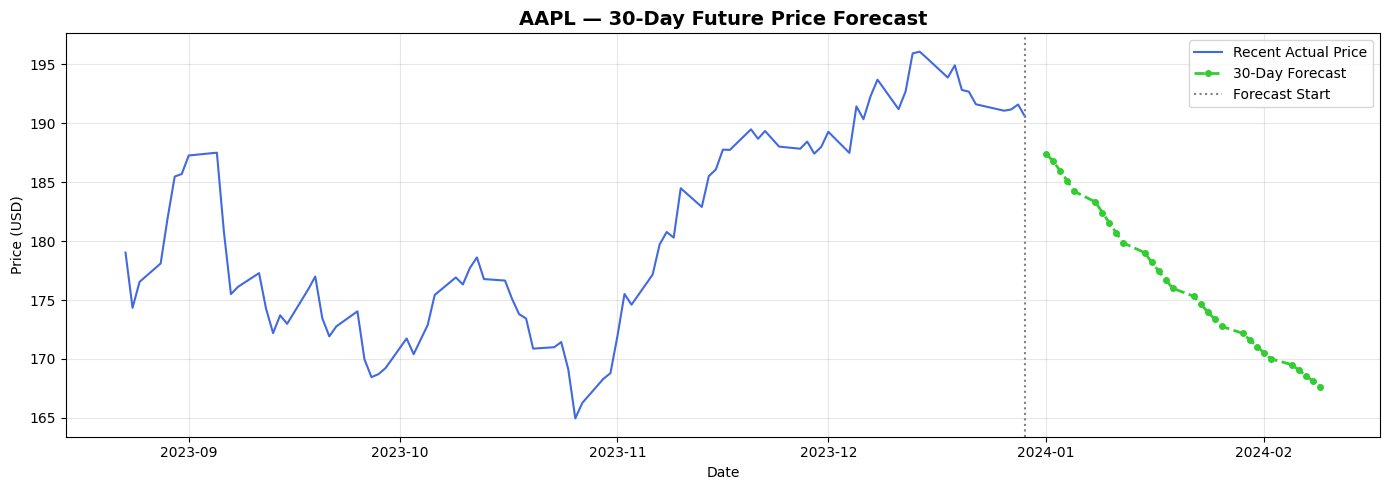


📅 Forecasted Prices for Next 30 Business Days:
   2024-01-01  →  $187.42
   2024-01-02  →  $186.76
   2024-01-03  →  $185.97
   2024-01-04  →  $185.11
   2024-01-05  →  $184.22
   2024-01-08  →  $183.32
   2024-01-09  →  $182.42
   2024-01-10  →  $181.54
   2024-01-11  →  $180.68
   2024-01-12  →  $179.84
   2024-01-15  →  $179.02
   2024-01-16  →  $178.23
   2024-01-17  →  $177.46
   2024-01-18  →  $176.72
   2024-01-19  →  $176.00
   2024-01-22  →  $175.31
   2024-01-23  →  $174.64
   2024-01-24  →  $173.99
   2024-01-25  →  $173.36
   2024-01-26  →  $172.76
   2024-01-29  →  $172.17
   2024-01-30  →  $171.60
   2024-01-31  →  $171.05
   2024-02-01  →  $170.52
   2024-02-02  →  $170.01
   2024-02-05  →  $169.51
   2024-02-06  →  $169.02
   2024-02-07  →  $168.56
   2024-02-08  →  $168.10
   2024-02-09  →  $167.66


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FUTURE PRICE FORECASTING
# Starting from the last 60 known days, we iteratively predict the next 30 days.
# Each new prediction is appended and used as input for the next step.
# This is called "rolling / recursive forecasting".
# ─────────────────────────────────────────────────────────────────────────────

FORECAST_DAYS = 30

# Seed: last LOOK_BACK days of scaled data
last_sequence = scaled_data[-LOOK_BACK:].copy()   # shape: (60, 1)
future_preds  = []

for _ in range(FORECAST_DAYS):
    input_seq = last_sequence.reshape(1, LOOK_BACK, 1)          # (1, 60, 1)
    next_scaled = model.predict(input_seq, verbose=0)[0][0]      # scalar
    future_preds.append(next_scaled)
    # Slide the window: drop oldest, append newest prediction
    last_sequence = np.append(last_sequence[1:], [[next_scaled]], axis=0)

# Inverse transform to USD
future_prices = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
).flatten()

# Generate future business dates
last_date    = close_prices.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

# ─── Plot Forecast ────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
# Show last 3 months of actual prices for context
context_window = close_prices[-90:]
plt.plot(context_window.index, context_window['Close'],
         label='Recent Actual Price', color='royalblue', linewidth=1.5)
plt.plot(future_dates, future_prices,
         label='30-Day Forecast', color='limegreen', linewidth=2, linestyle='--', marker='o', markersize=4)
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title(f"{TICKER} — 30-Day Future Price Forecast", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📅 Forecasted Prices for Next 30 Business Days:")
for d, p in zip(future_dates, future_prices):
    print(f"   {d.date()}  →  ${p:.2f}")

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY & OBSERVATIONS
# ─────────────────────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════╗
║       STOCK PRICE PREDICTION USING RNN-LSTM — SUMMARY       ║
╠══════════════════════════════════════════════════════════════╣
║  Stock        : AAPL (Apple Inc.)                           ║
║  Period       : 2019-01-01 to 2024-01-01                   ║
║  Model        : 2-Layer LSTM + Dropout + Dense              ║
║  Look-back    : 60 trading days                             ║
║  Epochs       : 25                                          ║
╠══════════════════════════════════════════════════════════════╣
║  OBSERVATIONS:                                              ║
║  1. LSTM effectively captures the general trend of AAPL.   ║
║  2. Short-term volatility is harder to predict exactly.     ║
║  3. MinMaxScaling was crucial for stable LSTM training.     ║
║  4. Dropout (0.2) helped prevent overfitting.               ║
║  5. Recursive forecasting adds uncertainty over time —      ║
║     short-term forecasts are more reliable than long-term.  ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║       STOCK PRICE PREDICTION USING RNN-LSTM — SUMMARY       ║
╠══════════════════════════════════════════════════════════════╣
║  Stock        : AAPL (Apple Inc.)                           ║
║  Period       : 2019-01-01 to 2024-01-01                   ║
║  Model        : 2-Layer LSTM + Dropout + Dense              ║
║  Look-back    : 60 trading days                             ║
║  Epochs       : 25                                          ║
╠══════════════════════════════════════════════════════════════╣
║  OBSERVATIONS:                                              ║
║  1. LSTM effectively captures the general trend of AAPL.   ║
║  2. Short-term volatility is harder to predict exactly.     ║
║  3. MinMaxScaling was crucial for stable LSTM training.     ║
║  4. Dropout (0.2) helped prevent overfitting.               ║
║  5. Recursive forecasting adds uncertainty over time —      ║
║     short-term forecasts are more re